# Load Results Marker Optimization.

## Prepare Notebook.

### Import Libraries.

In [1]:
import os
import sys
import yaml

import hydra
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable 
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.stats import gaussian_kde
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import torch
from tqdm import tqdm

sys.path.insert(0, "../../../../../shared_utils")
from data_utils import transform_validation_data, get_condition_data_from_file
from experiment_utils import get_forward_model

### Read Annotation File to Get Names of Protocol Colummns.

In [2]:
with os.environ["REPO_ROOT"] = os.path.abspath("../../../../..")

hydra.initialize(
    config_path="../../../../../inverse/loss_guidance/config"
):
    config = hydra.compose(
        config_name="run_inverse_constrained",
        overrides=[
            "paths=bloodplus_fm",
            "annotation=bloodplus",
            "sampling.N=10",
            "sampling.num_time_steps=20",
            "forward_model.num_time_steps=20",
            "constraints=default_all_cols"
        ]
    )

scatter_cols = config.annotation.scatter_columns
protocol_cols = config.annotation.protocol_columns
print(f"{protocol_cols=}")
print(f"{scatter_cols=}")

/tmp/ipykernel_348589/766258046.py:1: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with hydra.initialize(


protocol_cols=['gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]', 'days_of_culture']
scatter_cols=['FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width']


### Load Forward Model.

In [3]:
forward_model, (
    phi_model,
    target_prediction_model
) = get_forward_model(config)
forward_model.target_prediction_model.resc_model["model"].eval()
forward_model.forward_model.velocity_field.eval()
print(forward_model.target_prediction_model.resc_model["model"])
print(forward_model.forward_model.velocity_field)


PerturbationApproximatePosterior(
  (pert_approximate_posterior): ModuleDict(
    (encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=256, bias=True)
          (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout(p=0.1, inplace=False)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout(p=0.1, inplace=False)
        )
        (2): Sequential(
          (0): Linear(in_features=256, out_features=32, bias=True)
          (1): Identity()
        )
      )
    )
    (cell_type): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=32, out_features=24, bias=True)
          (1): Identity()
        )
      )
    )
  )
)


### Load Reference Medium Concentrations.

In [4]:
condition_metadata_path = "../../../../../project_folder/data/gdrive/table_metadata_theis_unmix8.xlsx" 
protocol_data, condition_adata = get_condition_data_from_file(
    phi_model.data_manager,
    condition_metadata_path,
    config.annotation.protocol_columns,
    config.annotation.log1p_exp_cols,
    config.annotation.log21p_exp_cols,
    config.annotation.protocol_obs_key_added,
    config.annotation.protocol_sep,
    config.annotation.one_hot_uns_key_added,
    config.annotation.protocol_obsm_key,
)
condition_adata

/lustre/groups/ml01/workspace/lorenzo.consoli/micromamba/envs/sc_exp_design/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


{'gm-csf_[ng_ml]': <ufunc 'log1p'>, 'tpo_[ng_ml]': <ufunc 'log1p'>, 'sr1_[nm]': <ufunc 'log1p'>, 'um171_[nm]': <ufunc 'log1p'>, 'um729_[µm]': <ufunc 'log1p'>, 'scf_[ng_ml]': <ufunc 'log1p'>, 'butyzamide_[nm]': <ufunc 'log1p'>, 'retinoic_acid_[µm]': <ufunc 'log1p'>, 'ldl_[ng_ml]': <ufunc 'log1p'>, 'il3_[ng_ml]': <ufunc 'log1p'>, 'o2_[%]': <ufunc 'log1p'>, 'days_of_culture': <ufunc 'log1p'>}


100%|██████████| 12/12 [00:00<00:00, 2635.30it/s]


AnnData object with n_obs × n_vars = 6 × 2
    obs: 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]', 'days_of_culture'
    obsm: 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]', 'days_of_culture', 'condition_concat'

### Read Original Annotation File.

In [5]:
experiment_id = "LPHO012"
additional_df_cols = ["experiment_number"]

condition_df = pd.read_excel(condition_metadata_path)
condition_df.columns = [col.replace("/", "_") for col in condition_df.columns]

all_df_cols = additional_df_cols + config.annotation.protocol_columns
lph_df = condition_df.loc[condition_df.experiment_id == experiment_id, all_df_cols]

X_sakurai = lph_df[lph_df["experiment_number"] == 210][protocol_cols].astype(float).values
X_sakurai_transf = np.log1p(X_sakurai) 
print(f"{X_sakurai.shape}")
lph_df

(1, 12)


,experiment_number,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
262,205,10,2.5,750,560.0,0.0,10,0,0,0,0.0,20,14
263,206,10,2.5,375,560.0,0.0,10,0,0,0,0.0,20,14
264,207,10,2.5,75,560.0,0.0,10,0,0,0,0.0,20,14
265,208,10,2.5,0,560.0,0.0,10,0,0,0,0.0,20,14
266,209,0,2.5,0,560.0,0.0,10,0,0,0,0.0,20,14
267,210,0,0.0,0,70.0,0.0,0,100,0,0,0.0,20,14


### Read Constraint File to Get Bounds per Protocol Colummn.

In [6]:
constraints_config_path = "../../../../../inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(constraints_config_path, "r") as fb:
    constraints_config = yaml.safe_load(fb)
ubound_dict = constraints_config["ubound_dict"]
lbound_dict = constraints_config["lbound_dict"]


### Read Bloodplus Annotated Data.

AnnData object with n_obs × n_vars = 499956 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

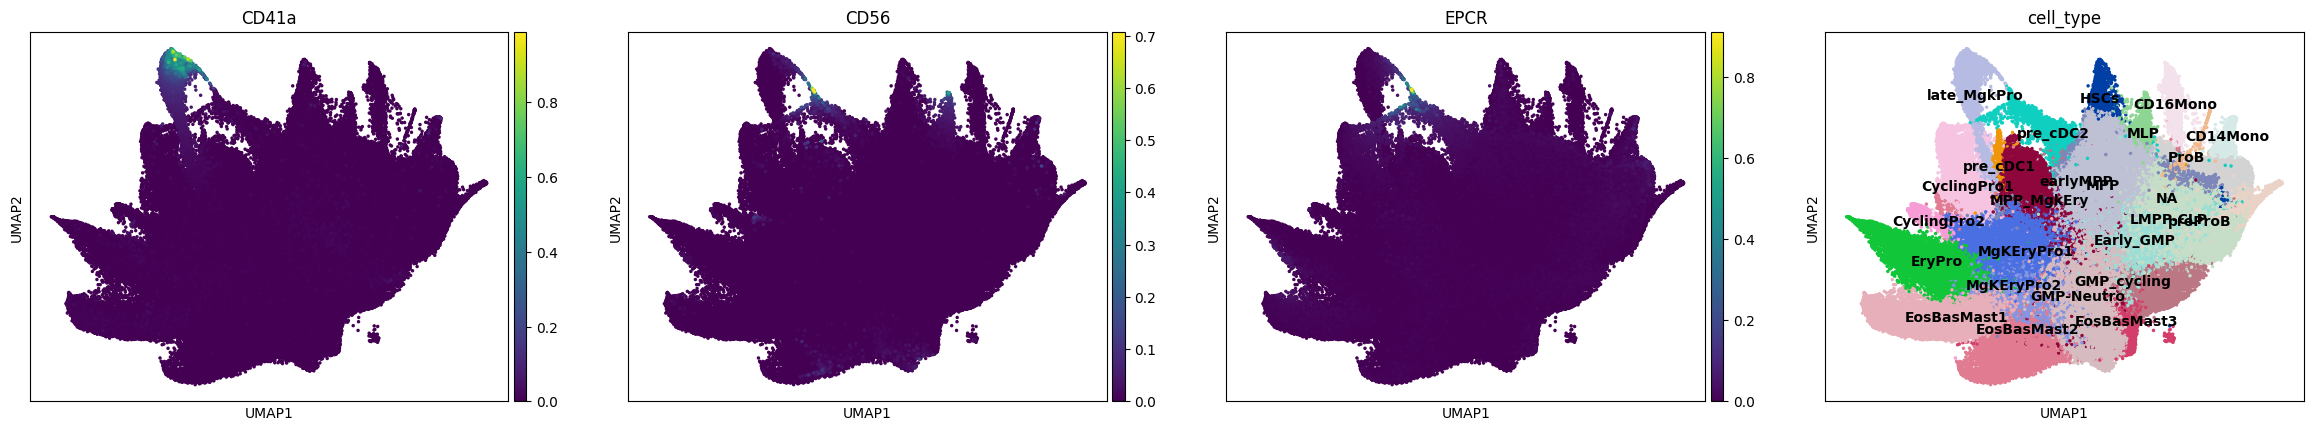

In [7]:
color = ["CD41a", "CD56", "EPCR", "cell_type"]
adata_path = "../../../../../project_folder/output/loops/data/loop1/adata_500k.h5ad"
adata = sc.read_h5ad(adata_path)
print(adata)
sc.pl.embedding(adata, "umap", color=color, s=25, frameon=True, legend_loc="on data")

### Transforming Annotated Data.

In [8]:
cell_state_repr = "X_channel_standardized+X_scatter_standardized"
feature_names = adata.var_names.to_list() + scatter_cols
train_adata_phi = phi_model.train_data.adata
adata = transform_validation_data(
    scatter_cols,
    train_adata_phi,
    adata,
)
X_ref = adata.obsm[cell_state_repr]
X_channel_ref = adata.obsm["X_channel_standardized"]
X_scatter_ref = adata.obsm["X_scatter_standardized"]
print(f"{adata=}")
print(f"{X_ref.shape=}")
print(f"{X_channel_ref.shape=}")
print(f"{X_scatter_ref.shape=}")
print(f"{feature_names=}")

adata=AnnData object with n_obs × n_vars = 499956 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors

### Fit Label Encoder.

In [9]:
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = ct_le.classes_.tolist()

### Predicting Cell Type on Real Data.

In [10]:
pred_cts_list = []
chunck_size = 50_000
for batch_idxs in range(0, len(adata), chunck_size):
    X_ref_batch = torch.from_numpy(X_ref[batch_idxs:batch_idxs+chunck_size]).to(torch.float32).to(phi_model.device)
    with torch.no_grad():
        ct_logits = forward_model.target_prediction_model(X_ref_batch)["cell_type"]
    ct_probs = torch.nn.functional.softmax(ct_logits, dim=-1).detach().cpu().numpy()
    ct_label = ct_probs.argmax(1)
    ct_names = ct_le.inverse_transform(ct_label)
    pred_cts_list.append(ct_names)
pred_ct = np.concatenate(pred_cts_list, axis=0)
adata.obs["pred_cell_type"] = pred_ct


### Read Optimization Data.

In [11]:
# ---- Prepare to Collect Records ----
all_candidates_dfs = []
all_fdw_results = []
all_inv_results = []

# ---- Base Optimization Directory ----
opt_base_dir = "../../../../../project_folder/output/inverse/loss_guidance/bloodplus_inverse_marker_opt_0999threshold"
opt_modes_list = os.listdir(opt_base_dir)
n_opt_modes = len(opt_modes_list)
print(f"---- Reading Base Optimization Directory, {n_opt_modes} Optimization Modes found ----")

# ---- Optimization Mode Loop ----
for opt_mode_idx, opt_mode in enumerate(opt_modes_list):
    mode_dir = os.path.join(opt_base_dir, opt_mode)
    target_markers_list = os.listdir(mode_dir)
    n_target_markers = len(target_markers_list)
    print(f"\t---- (O: {opt_mode_idx + 1}/{n_opt_modes}) Reading Data for Optimization Mode {opt_mode}, {n_target_markers=} Target Markers Found ----")

    # ---- Target Marker Loop ----
    for tgt_marker_idx, tgt_marker in enumerate(target_markers_list):
        tgt_marker_dir = os.path.join(mode_dir, tgt_marker)
        runs_list = os.listdir(tgt_marker_dir) 
        n_runs = len(runs_list)
        print(
            f"\t\t---- (O:{opt_mode_idx + 1}/{n_opt_modes}, M:{tgt_marker_idx + 1}/{n_target_markers}) "
            f"Reading Data for Marker {tgt_marker}, {n_runs=} Runs Found ----"
        )

        # ---- Runs Loop ----
        for run_idx, run in enumerate(runs_list):
            print(
                f"\t\t\t---- (O:{opt_mode_idx + 1}/{n_opt_modes}, M:{tgt_marker_idx + 1}/{n_target_markers}, R:{run_idx + 1}/{n_runs}) "
                f"Reading Data for Run {run} ----"
            )
            run_dir = os.path.join(tgt_marker_dir, run)

            # create file names
            candidates_csv_path = os.path.join(run_dir, "candidates.csv")
            fwd_results_path = os.path.join(run_dir, "fwd_results.npz")
            inv_results_path = os.path.join(run_dir, "inverse_results.npz")

            # read candidates df and arrays
            run_candidates_df = pd.read_csv(candidates_csv_path)
            fwd_results = dict(np.load(fwd_results_path))
            inv_results = dict(np.load(inv_results_path))

            # update data
            run_candidates_df["opt_mode"] = opt_mode
            run_candidates_df["tgt_marker"] = tgt_marker
            run_candidates_df["run"] = run

            fwd_results["opt_mode"] = opt_mode
            fwd_results["tgt_marker"] = tgt_marker
            fwd_results["run"] = run

            inv_results["opt_mode"] = opt_mode
            inv_results["tgt_marker"] = tgt_marker
            inv_results["run"] = run

            # store to list
            all_candidates_dfs.append(run_candidates_df)
            all_fdw_results.append(fwd_results)
            all_inv_results.append(inv_results)

# ---- Concatenate and display ----
main_df = pd.concat(all_candidates_dfs, axis=0)
main_df

---- Reading Base Optimization Directory, 6 Optimization Modes found ----
	---- (O: 1/6) Reading Data for Optimization Mode penalized_oxy_days-constant, n_target_markers=1 Target Markers Found ----
		---- (O:1/6, M:1/1) Reading Data for Marker CD56, n_runs=50 Runs Found ----
			---- (O:1/6, M:1/1, R:1/50) Reading Data for Run 2026-05-11_13-41-32_5913c770 ----
			---- (O:1/6, M:1/1, R:2/50) Reading Data for Run 2026-05-11_13-30-44_cc859fc9 ----
			---- (O:1/6, M:1/1, R:3/50) Reading Data for Run 2026-05-11_13-19-55_be6ff584 ----
			---- (O:1/6, M:1/1, R:4/50) Reading Data for Run 2026-05-11_13-39-03_37106332 ----
			---- (O:1/6, M:1/1, R:5/50) Reading Data for Run 2026-05-11_13-43-35_1b7c7622 ----
			---- (O:1/6, M:1/1, R:6/50) Reading Data for Run 2026-05-11_13-37-17_687c4cb3 ----
			---- (O:1/6, M:1/1, R:7/50) Reading Data for Run 2026-05-11_13-26-29_800b1cd2 ----
			---- (O:1/6, M:1/1, R:8/50) Reading Data for Run 2026-05-11_13-25-44_6f03789c ----
			---- (O:1/6, M:1/1, R:9/50) Readi

			---- (O:6/6, M:1/2, R:7/50) Reading Data for Run 2026-05-11_11-20-18_38463fe6 ----
			---- (O:6/6, M:1/2, R:8/50) Reading Data for Run 2026-05-11_11-37-39_84b46349 ----
			---- (O:6/6, M:1/2, R:9/50) Reading Data for Run 2026-05-11_11-34-32_f1994323 ----
			---- (O:6/6, M:1/2, R:10/50) Reading Data for Run 2026-05-11_11-17-33_d71cabec ----
			---- (O:6/6, M:1/2, R:11/50) Reading Data for Run 2026-05-11_11-25-36_f17e1e19 ----
			---- (O:6/6, M:1/2, R:12/50) Reading Data for Run 2026-05-11_11-32-44_40078fa0 ----
			---- (O:6/6, M:1/2, R:13/50) Reading Data for Run 2026-05-11_11-33-21_f04c5d67 ----
			---- (O:6/6, M:1/2, R:14/50) Reading Data for Run 2026-05-11_11-28-37_3804cf2b ----
			---- (O:6/6, M:1/2, R:15/50) Reading Data for Run 2026-05-11_11-17-33_bebad115 ----
			---- (O:6/6, M:1/2, R:16/50) Reading Data for Run 2026-05-11_11-37-23_55d98392 ----
			---- (O:6/6, M:1/2, R:17/50) Reading Data for Run 2026-05-11_11-28-45_2fa1a0d9 ----
			---- (O:6/6, M:1/2, R:18/50) Reading Data f

,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],...,cfg:constraints:ubound_dict:gm-csf_[ng_ml],cfg:constraints:ubound_dict:tpo_[ng_ml],cfg:constraints:ubound_dict:um171_[nm],cfg:constraints:ubound_dict:um729_[µm],cfg:constraints:ubound_dict:sr1_[nm],cfg:constraints:ubound_dict:scf_[ng_ml],cfg:constraints:ubound_dict:butyzamide_[nm],cfg:constraints:ubound_dict:retinoic_acid_[µm],cfg:constraints:ubound_dict:ldl_[ng_ml],cfg:constraints:ubound_dict:il3_[ng_ml]
0,CD56:2026-05-11_13-41-32_5913c770:0,12.358505,1.078334,767.870240,7751.698000,1.475643,89.836210,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CD56:2026-05-11_13-41-32_5913c770:1,15.656239,2.030912,613.562900,7842.546400,0.000000,94.251380,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CD56:2026-05-11_13-41-32_5913c770:2,8.440626,3.852150,3600.013400,0.000000,150.501360,49.383305,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CD56:2026-05-11_13-41-32_5913c770:3,16.277575,1.774903,542.713440,8825.342000,0.000000,90.888770,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CD56:2026-05-11_13-41-32_5913c770:4,49.659850,0.000000,310.771800,0.000000,49.911327,0.000000,253.339770,0.000000,0.395126,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,CD56:2026-05-11_12-15-16_77b0eef0:5,9.075216,2.395259,707.499900,1298.893100,0.000000,52.623646,0.000000,0.098236,9.979935,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,CD56:2026-05-11_12-15-16_77b0eef0:6,9.720523,2.392286,799.433900,1419.605700,0.028785,36.161633,0.000000,0.188612,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,CD56:2026-05-11_12-15-16_77b0eef0:7,5.507559,1.156551,6.730537,0.283726,1.131536,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,CD56:2026-05-11_12-15-16_77b0eef0:8,2.861754,0.082681,89.503650,122.835014,0.087862,0.202928,84.412636,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Group Data by Target Marker.

In [12]:
markers_df_dict = {}
for marker_names, markers_df in main_df.groupby(by="cfg:loss:target_marker_names"):
    markers_df_dict[marker_names] = markers_df
print(markers_df_dict.keys())

dict_keys(["['CD56']", "['EPCR']"])


### Filter Data Frames Based on Condition Columns.

In [13]:
# ---- Define Margin for Filtering ----
margin = 0.1

# ----  Target Markers Loop ----
print("---- Filtering Results ----")
filtered_markers_df_dict = {}
for marker_names, marker_df in markers_df_dict.items():
    print(f"\t---- Processing Results for Markers {marker_names} ----")
    # define mask for all columns
    marker_mask = np.full(marker_df.shape[0], True)

    # ----  Protocol Columns Loop ----
    for col in protocol_cols:
        # get col bounds
        col_ubound = ubound_dict[col]
        col_lbound = lbound_dict[col]
        print(f"\t\t---- Markers: {marker_names}. Processing Column {col} -> U: {col_ubound}, L: {col_lbound} ----")

        # get col values and mask
        col_values = marker_df[col]
        col_mask_ubound_mask = col_values <= col_ubound*(1 + margin)
        col_mask_lbound_mask = col_values >= col_lbound*(1 - margin)

        # get masks for current column
        old_mask = marker_mask
        lbound_marker_mask = marker_mask & col_mask_lbound_mask
        ubound_marker_mask = marker_mask & col_mask_ubound_mask
        marker_mask = marker_mask & col_mask_ubound_mask & col_mask_lbound_mask

        # get number of solutions
        n_previously_accepted_solutions = old_mask.sum()
        n_accepted_solutions = marker_mask.sum()
        n_solutions_passing_ubound = col_mask_ubound_mask.sum()
        n_solutions_passing_lbound = col_mask_lbound_mask.sum()
        n_solutions_passing_ubound_and_previous_constraints = ubound_marker_mask.sum()
        n_solutions_passing_lbound_and_previous_constraints = lbound_marker_mask.sum()
        print(f"\t\t\t --- Number Previously Accepted Solutions {n_previously_accepted_solutions} ---")
        print(f"\t\t\t --- Number Currently Accepted Solutions {n_accepted_solutions} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Upper Bound {n_solutions_passing_ubound} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Lower Bound {n_solutions_passing_lbound} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Upper Bound and Previous Constraints {n_solutions_passing_ubound_and_previous_constraints} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Lower Bound and Previous Constraints {n_solutions_passing_lbound_and_previous_constraints} ---")


        # write values for constraint on current column
        marker_df[f"passes_constraints:{col}:ubound"] = col_mask_ubound_mask
        marker_df[f"passes_constraints:{col}:lbound"] = col_mask_ubound_mask

    # write values for all constraints
    n_all_solutions = marker_df.shape[0]
    n_accepted_solutions = marker_mask.sum()
    marker_df["passes_constraints:all"] = marker_mask
    filtered_markers_df_dict[marker_names] = marker_df
    print(f"\t\t\t--- Marker {marker_names} Finished, Out of {n_all_solutions} there are {n_accepted_solutions} Passing with Margin {margin} ----")

# final loop for displaying synthetically the results
for marker_names, marker_df in filtered_markers_df_dict.items():
    n_all_solutions = marker_df.shape[0]
    n_accepted_solutions = marker_df["passes_constraints:all"].sum()
    print(f"--- Marker {marker_names}: Out of {n_all_solutions} there are {n_accepted_solutions} Passing with Margin {margin} ----")


---- Filtering Results ----
	---- Processing Results for Markers ['CD56'] ----
		---- Markers: ['CD56']. Processing Column gm-csf_[ng_ml] -> U: 10.0, L: 0.0 ----
			 --- Number Previously Accepted Solutions 1410 ---
			 --- Number Currently Accepted Solutions 1009 ---
			 --- Number of Solution Satisfying Upper Bound 1009 ---
			 --- Number of Solution Satisfying Lower Bound 1410 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 1009 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 1410 ---
		---- Markers: ['CD56']. Processing Column tpo_[ng_ml] -> U: 2.5, L: 0.0 ----
			 --- Number Previously Accepted Solutions 1009 ---
			 --- Number Currently Accepted Solutions 946 ---
			 --- Number of Solution Satisfying Upper Bound 1334 ---
			 --- Number of Solution Satisfying Lower Bound 1410 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 946 ---
			 --- Number of Solution Satisfying Lower Bound and Previ

## Analyse Cell Level Optimization Results.

### Filtering the Solutions with Cell Level Objective Type.

In [14]:
# ---- Prepare Store for Cell Level Optimization Data ----
obj_type_of_interest = "cell"
cell_level_filtered_markers_df_dict = {}

# ---- Loop over Data Frames ----
print("---- Retrieving Cell Level Optimization Results ----")
for marker_names, marker_df in filtered_markers_df_dict.items():
    # prepare masks
    obj_type_mask = marker_df["cfg:loss:obj_type"] == obj_type_of_interest
    passes_constraint_mask = marker_df["passes_constraints:all"]
    mask =  obj_type_mask & passes_constraint_mask

    # get number of observations for each case
    n_tot_runs_marker = marker_df.shape[0]
    n_obj_type_runs_marker = obj_type_mask.sum()
    n_obj_type_runs_marker_passing_filtering = mask.sum()

    # filter data frame
    cell_marker_df = marker_df[mask]
    cell_level_filtered_markers_df_dict[marker_names] = cell_marker_df

    print(
        f"\t---- Target Markers {marker_names}: Total of {n_tot_runs_marker} "
        f"of Which {n_obj_type_runs_marker} for objective type {obj_type_of_interest}. "
        f"Out of these {n_obj_type_runs_marker_passing_filtering} pass all filters ----"
    )


---- Retrieving Cell Level Optimization Results ----
	---- Target Markers ['CD56']: Total of 1410 of Which 740 for objective type cell. Out of these 92 pass all filters ----
	---- Target Markers ['EPCR']: Total of 2000 of Which 920 for objective type cell. Out of these 158 pass all filters ----


### Align Format of Forward Solutions.

In [15]:
fwd_results_mapped = {}
for res_dict in all_fdw_results:
    # get keys
    res_dict = res_dict.copy()
    opt_mode = res_dict.pop("opt_mode")
    tgt_marker = res_dict.pop("tgt_marker")
    run = res_dict.pop("run")

    # append with key
    key = (opt_mode, tgt_marker, run)
    fwd_results_mapped[key] = res_dict

### Align Format of Inverse Solutions.

In [16]:
inv_results_mapped = {}
for res_dict in all_inv_results:
    # get keys
    res_dict = res_dict.copy()
    opt_mode = res_dict.pop("opt_mode")
    tgt_marker = res_dict.pop("tgt_marker")
    run = res_dict.pop("run")

    # append with key
    key = (opt_mode, tgt_marker, run)
    inv_results_mapped[key] = res_dict

## Analyse Target Marker.

### Collect Statistics for Target Marker Expression.

In [17]:
# ---- Create Store for Statistics Data Frames ----
target_markers_stats_dfs_dict = {}

# ---- Loop over Data Frames ----
print("---- Retrieving Mean and Variance for Target Markers ----")
for marker_names, marker_df in cell_level_filtered_markers_df_dict.items():
    n_marker_solutions = marker_df.shape[0]
    print(f"\t---- Processing Marker {marker_names}, {n_marker_solutions} solutions found ----")
    # get indices of target markers
    marker_names = eval(marker_names)
    marker_idxs = [feature_names.index(name) for name in marker_names]

    # prepare store for marker results
    marker_records = []

    # ---- Loop over Data Frames ----
    for ridx, row_data in marker_df.iterrows():
        # get row metadata
        row_data_dict = row_data.to_dict()
        opt_mode = row_data_dict["opt_mode"]
        tgt_marker = row_data_dict["tgt_marker"]
        run = row_data_dict["run"]

        # parse sample identifier
        sample_id = row_data_dict["sample_id"]
        target_marker, run_id, sample_idx = sample_id.split(":")
        sample_idx = int(sample_idx)

        # get forward results for current run
        key = (opt_mode, tgt_marker, run)
        fwd_dict_run = fwd_results_mapped[key].copy()
        inv_dict_run = inv_results_mapped[key].copy()

        # handle value shape for lambda history
        lambda_history = inv_dict_run.pop("lambda_history")[0]
        inv_dict_run["lambda_history"] = lambda_history
        n_samples = lambda_history.shape[0]

        # handle shape for xstar
        xstar = inv_dict_run.pop("xstar")[0]
        inv_dict_run["xstar"] = np.repeat(xstar[None], n_samples, axis=0)

        # index for current sample
        fwd_dict = {k: v[sample_idx] for k, v in fwd_dict_run.items()}
        inv_dict = {k: v[sample_idx] for k, v in inv_dict_run.items()}

        # compute statistics for features
        X = fwd_dict["X"]
        X_mean = X.mean(0)
        X_std = X.std(0)
        X_var = X.var(0)

        # compute mean cell type probabilities
        ct_probs = fwd_dict["ct_probs"]
        mean_ct_probs = ct_probs.mean(0)

        # get target markers
        X_tgt_marker = X[..., marker_idxs]
        X_mean_tgt_marker = X_mean[marker_idxs]
        X_std_tgt_marker = X_std[marker_idxs]
        X_var_tgt_marker = X_var[marker_idxs]
        xstar_tgt = xstar[marker_idxs]

        # compute distance from target marker
        X_mean_of_dists_to_target = np.sum((X_tgt_marker - xstar_tgt)**2, axis=-1).mean(0).item()
        X_std_of_dists_to_target = np.sum((X_tgt_marker - xstar_tgt)**2, axis=-1).std(0).item()
        X_var_of_dists_to_target = np.sum((X_tgt_marker - xstar_tgt)**2, axis=-1).var(0).item()
        X_dist_of_mean_to_target = ((X_mean_tgt_marker - xstar_tgt)**2).mean(0).item()

        # compute distance from sakurai
        X_prot = row_data[protocol_cols].astype(float).values[None]
        X_prot_transf = np.log1p(X_prot)
        dist_sakurai = ((X_prot_transf - X_sakurai_transf)**2).sum(-1)[0].item()

        # store as dictionary
        X_mean_tgt_marker_dict = {
            name: X_mean_tgt_marker[idx].item() for idx, name in enumerate(marker_names)
        }
        X_var_tgt_marker_dict = {
            name: X_var_tgt_marker[idx].item() for idx, name in enumerate(marker_names)
        }
        xstar_tgt_marker_dict = {
            name: xstar_tgt[idx].item() for idx, name in enumerate(marker_names)
        }
        mean_ct_probs_dict = {
            name: mean_ct_probs[idx].item() for idx, name in enumerate(classes)
        }
        protocol_values_dict = {
            k:v for k, v in row_data.items() if k in protocol_cols
        }

        # create row and update collections
        row_record = {
            **{f"{k}_mean": v for k, v in X_mean_tgt_marker_dict.items()},
            **{f"{k}_var": v for k, v in X_var_tgt_marker_dict.items()},
            **{f"{k}_target": v for k, v in xstar_tgt_marker_dict.items()},
            **mean_ct_probs_dict,
            **protocol_values_dict,
            "dist_sakurai": dist_sakurai,
            "mean_of_dists_to_target_marker": X_mean_of_dists_to_target,
            "std_of_dists_to_target_marker": X_std_of_dists_to_target,
            "var_of_dists_to_target_marker": X_var_of_dists_to_target,
            "dist_of_mean_to_target": X_dist_of_mean_to_target,
        }
        row_record["opt_mode"] = opt_mode
        row_record["tgt_marker"] = tgt_marker
        row_record["run"] = run
        row_record["sample_idx"] = sample_idx
        marker_records.append(row_record)

    marker_stats_df = pd.DataFrame(marker_records)
    target_markers_stats_dfs_dict[tgt_marker] = marker_stats_df


---- Retrieving Mean and Variance for Target Markers ----
	---- Processing Marker ['CD56'], 92 solutions found ----
	---- Processing Marker ['EPCR'], 158 solutions found ----


### Mean-Var Plot and Cell Type Proportions.

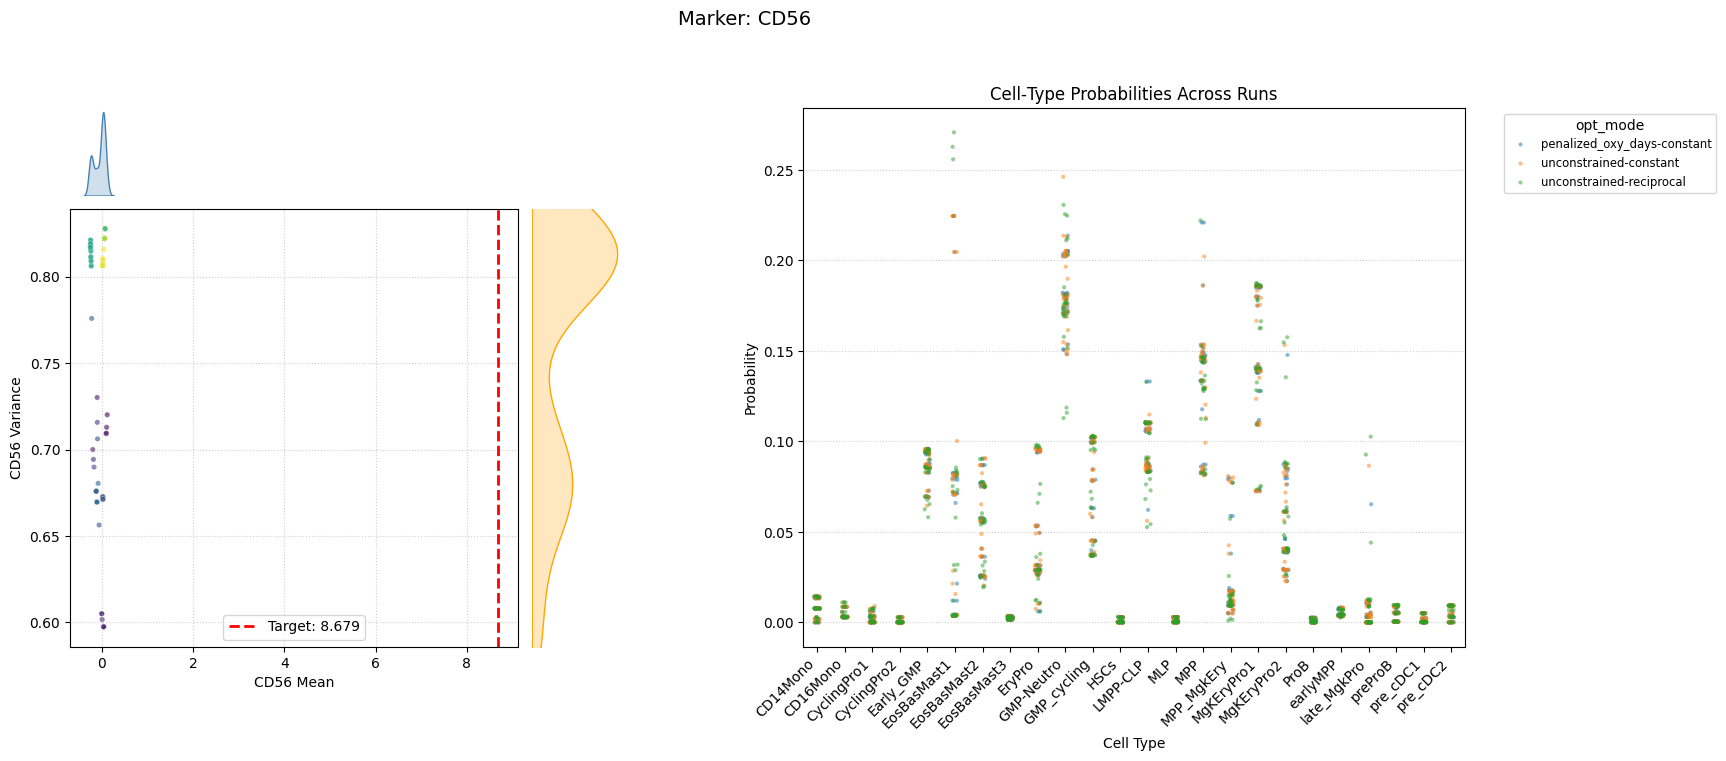

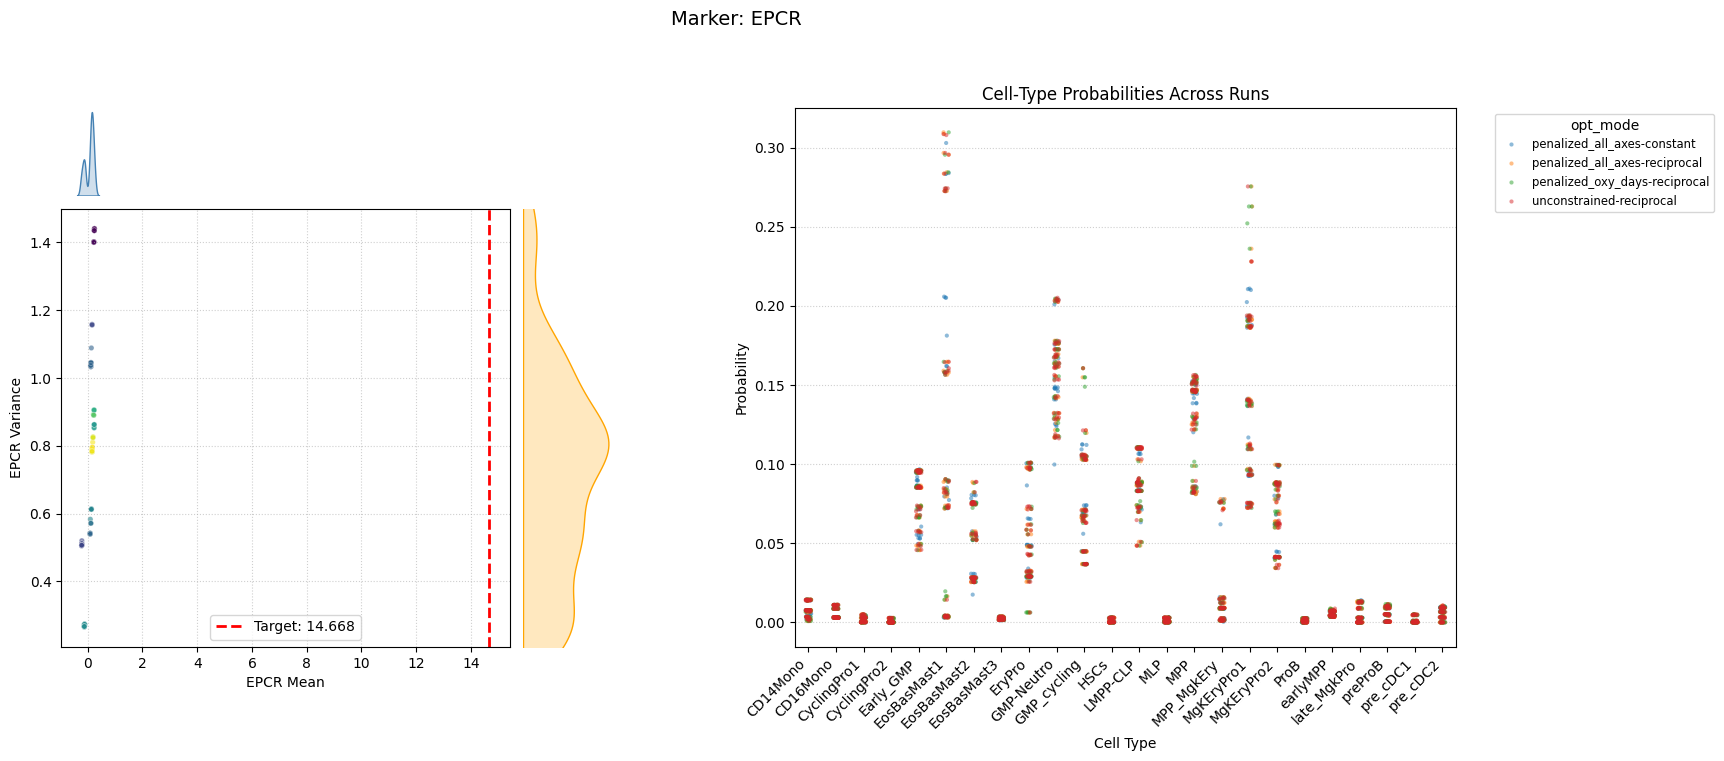

In [18]:
# ----- Metadata columns (adjust if needed) -----
metadata_cols = ['opt_mode', 'tgt_marker', 'run', 'sample_idx']

# ----- Loop over each target marker -----
for marker_tuple, df in target_markers_stats_dfs_dict.items():
    if len(df) == 0: continue
    hue_col = 'opt_mode'                     # used only for the right strip plot
    marker_name = '_'.join(marker_tuple) if isinstance(marker_tuple, tuple) else str(marker_tuple)

    # Marker‑specific column names
    mean_col   = f"{marker_name}_mean"
    var_col    = f"{marker_name}_var"
    target_col = f"{marker_name}_target"

    # Cell‑type probability columns
    marker_specific = [mean_col, var_col, target_col, "point_density"] + protocol_cols
    celltype_cols = classes

    # Melt for the right strip plot
    df_melt = df.melt(
        id_vars=[hue_col],
        value_vars=celltype_cols,
        var_name='CellType',
        value_name='Probability'
    )

    # ----- Compute point density -----
    points = df[[mean_col, var_col]].values.T
    kde = gaussian_kde(points)
    df['point_density'] = kde(points)

    # ----- Create figure with GridSpec -----
    fig = plt.figure(figsize=(18, 7))
    gs_outer = fig.add_gridspec(1, 2, width_ratios=[1, 1.2], wspace=0.3)

    # Left side: sub‑gridspec for scatter + marginals
    gs_left = gs_outer[0].subgridspec(2, 2, width_ratios=[5, 1], height_ratios=[1, 5],
                                      hspace=0.05, wspace=0.05)
    ax_top    = fig.add_subplot(gs_left[0, 0])   # x marginal
    ax_main   = fig.add_subplot(gs_left[1, 0])   # main scatter
    ax_right_marg = fig.add_subplot(gs_left[1, 1])   # y marginal

    # Right side: strip plot
    ax_right = fig.add_subplot(gs_outer[1])

    # ----- LEFT SCATTER PLOT (coloured by density, no colour bar) -----
    sns.scatterplot(data=df, x=mean_col, y=var_col,
                    hue='point_density', palette='viridis',
                    alpha=0.6, s=15, ax=ax_main, legend=False)

    # Target vertical line
    target_val = df[target_col].iloc[0]
    ax_main.axvline(target_val, color='red', linestyle='--', linewidth=2,
                    label=f'Target: {target_val:.3f}')
    ax_main.set_xlabel(f'{marker_name} Mean')
    ax_main.set_ylabel(f'{marker_name} Variance')
    ax_main.legend()
    ax_main.grid(True, linestyle=':', alpha=0.6)

    # ----- MARGINALS -----
    sns.kdeplot(data=df, x=mean_col, fill=True, color='steelblue', ax=ax_top)
    ax_top.set_xlim(ax_main.get_xlim())
    ax_top.axis('off')
    ax_top.grid(False)

    sns.kdeplot(data=df, y=var_col, fill=True, color='orange', ax=ax_right_marg)
    ax_right_marg.set_ylim(ax_main.get_ylim())
    ax_right_marg.axis('off')
    ax_right_marg.grid(False)

    # ----- RIGHT STRIP PLOT -----
    sns.stripplot(data=df_melt, x='CellType', y='Probability', hue=hue_col,
                  jitter=True, dodge=False, size=3, alpha=0.5, ax=ax_right)
    ax_right.set_xlabel('Cell Type')
    ax_right.set_ylabel('Probability')
    ax_right.set_title('Cell‑Type Probabilities Across Runs')
    ax_right.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
                    fontsize='small', title=hue_col)
    ax_right.grid(True, axis='y', linestyle=':', alpha=0.6)
    plt.setp(ax_right.get_xticklabels(), rotation=45, ha='right')

    fig.suptitle(f'Marker: {marker_name}', fontsize=14, y=1.02)
    plt.show()
    # Uncomment to save:
    # plt.savefig(f'plots/{marker_name}_with_density.png', dpi=150, bbox_inches='tight')


### Plot Protocol Columns against Target Marker Statistics.

/tmp/ipykernel_348589/1228503491.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


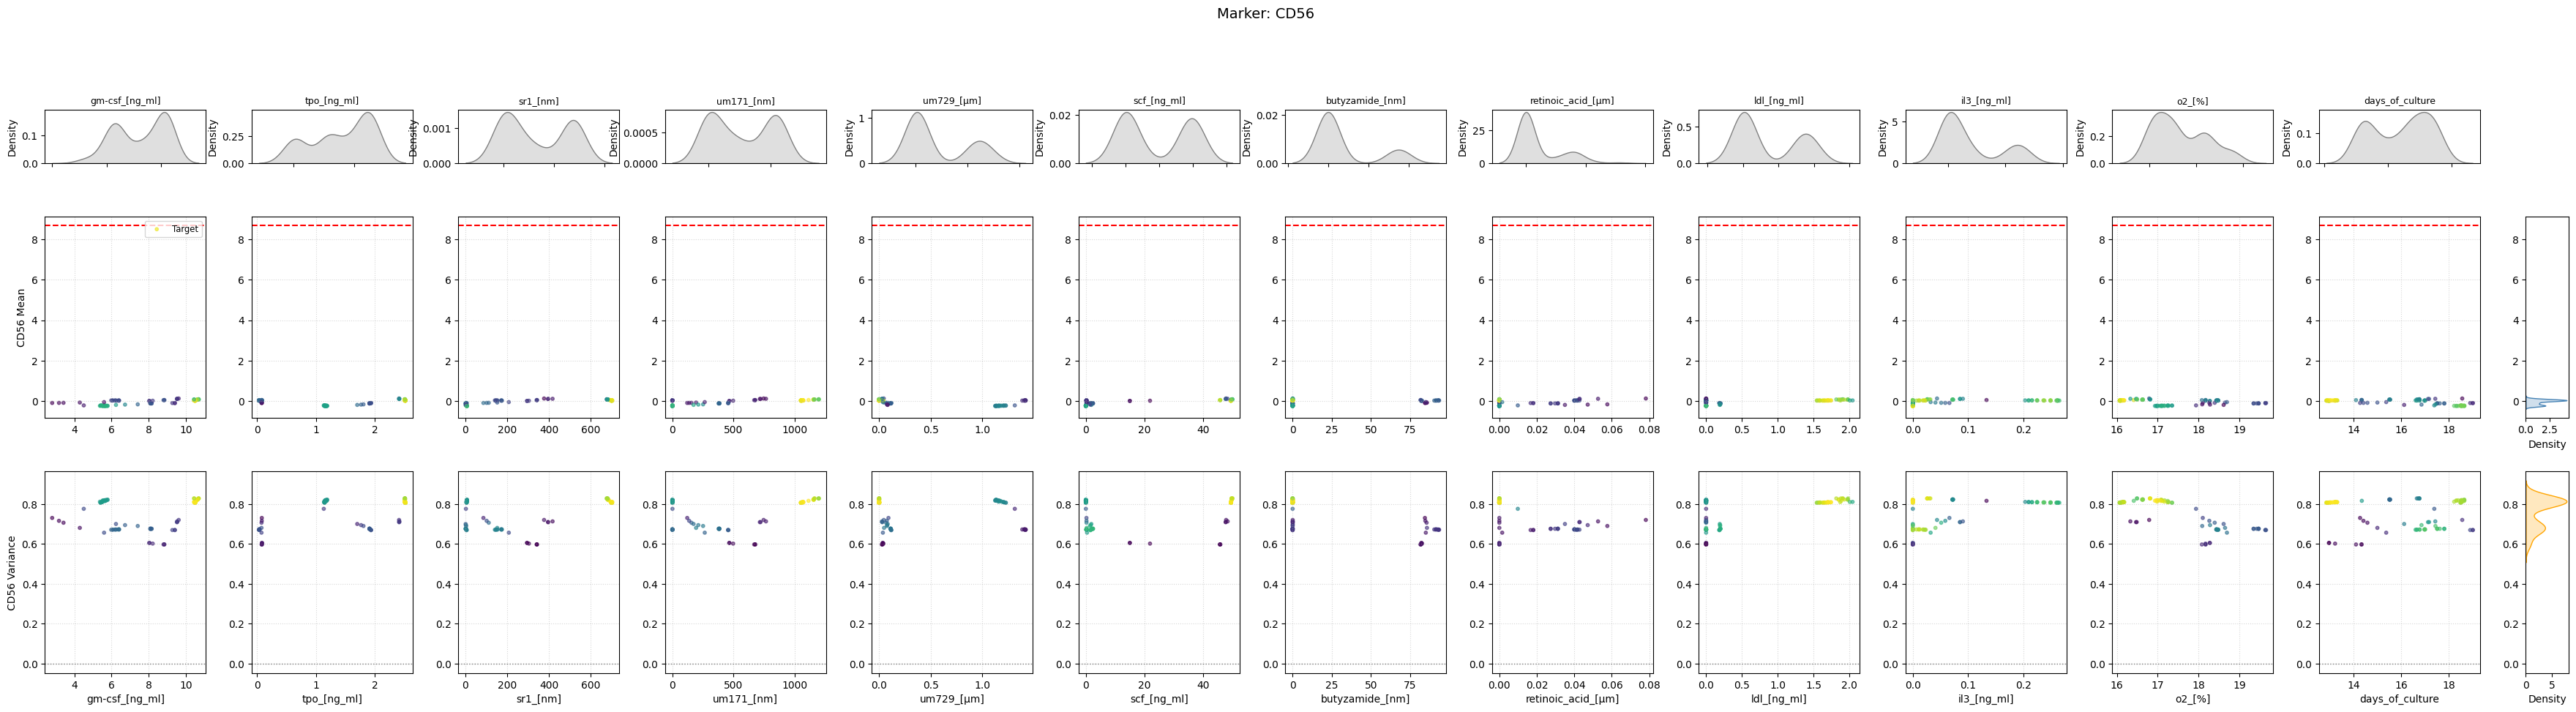

/tmp/ipykernel_348589/1228503491.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


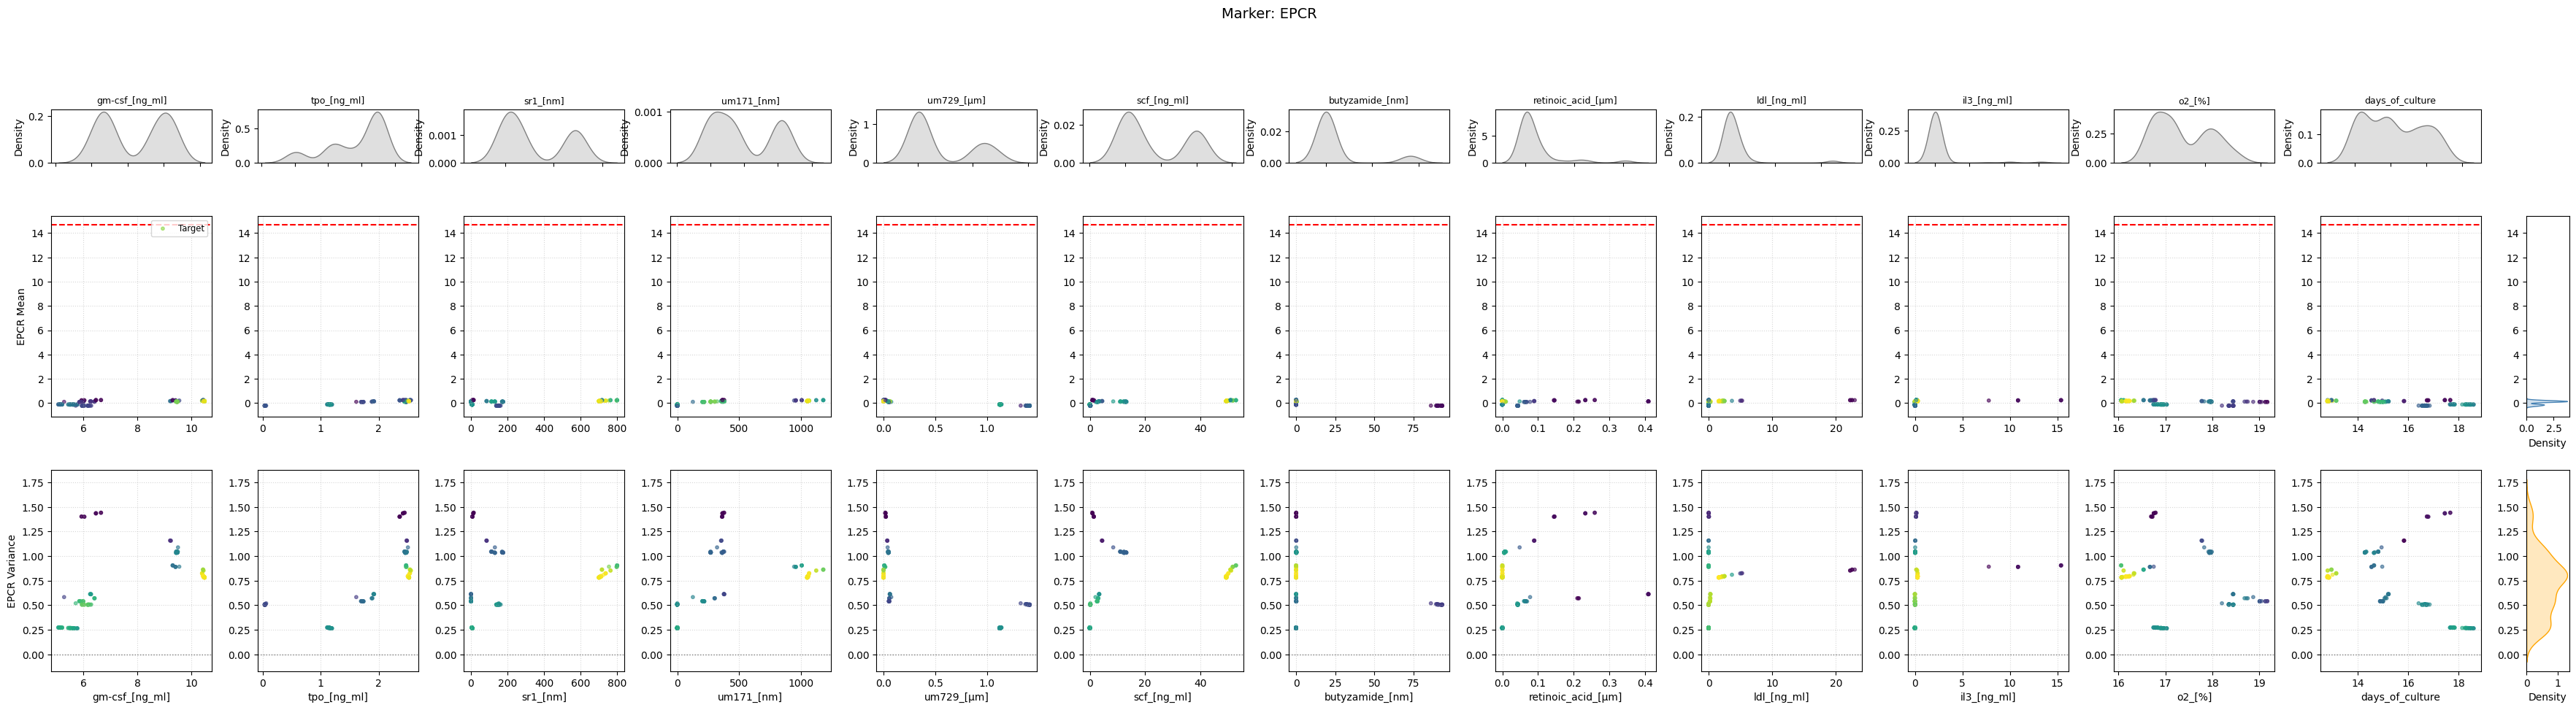

In [19]:
# ----- For each marker: x‑marginals (top row), mean & variance scatters, y‑marginals (right) -----
for marker_name, df in target_markers_stats_dfs_dict.items():
    if len(df) == 0: continue
    mean_col   = f"{marker_name}_mean"
    var_col    = f"{marker_name}_var"
    target_col = f"{marker_name}_target"
    target_val = df[target_col].iloc[0]

    n_prot = len(protocol_cols)

    # ----- Compute 2D joint densities for every scatter -----
    # Mean row
    densities_mean = []
    for pcol in protocol_cols:
        xy = df[[pcol, mean_col]].values.T
        kde = gaussian_kde(xy)
        dens = kde(xy)  # evaluate at each point
        densities_mean.append(dens)
    # Variance row
    densities_var = []
    for pcol in protocol_cols:
        xy = df[[pcol, var_col]].values.T
        kde = gaussian_kde(xy)
        dens = kde(xy)
        densities_var.append(dens)

    # ----- Figure & GridSpec -----
    fig = plt.figure(figsize=(3.5 * n_prot + 2.5, 10))
    gs = fig.add_gridspec(3, n_prot + 1,
                          width_ratios=[3]*n_prot + [0.8],
                          height_ratios=[0.8, 3, 3],
                          hspace=0.35, wspace=0.3)

    # ----- Top row: x‑marginals (protocol distribution per column) -----
    ax_xmarg = []
    for i in range(n_prot):
        ax = fig.add_subplot(gs[0, i])
        ax_xmarg.append(ax)

    # ----- Middle row: Mean scatters -----
    ax_mean_list = []
    for i in range(n_prot):
        if i == 0:
            ax = fig.add_subplot(gs[1, i])
        else:
            ax = fig.add_subplot(gs[1, i], sharey=ax_mean_list[0])
        ax_mean_list.append(ax)
    ax_mean_marg = fig.add_subplot(gs[1, n_prot], sharey=ax_mean_list[0])

    # ----- Bottom row: Variance scatters -----
    ax_var_list = []
    for i in range(n_prot):
        if i == 0:
            ax = fig.add_subplot(gs[2, i])
        else:
            ax = fig.add_subplot(gs[2, i], sharey=ax_var_list[0])
        ax_var_list.append(ax)
    ax_var_marg = fig.add_subplot(gs[2, n_prot], sharey=ax_var_list[0])

    # Link x‑axes between mean and variance rows (same protocol column)
    for i in range(n_prot):
        ax_var_list[i].sharex(ax_mean_list[i])

    # ----- Plot x‑marginals (top) -----
    for ax, pcol in zip(ax_xmarg, protocol_cols):
        sns.kdeplot(data=df, x=pcol, fill=True, color='gray', ax=ax)
        ax.set_title(pcol, fontsize=9)
        ax.set_xlabel('')
        ax.set_xticklabels([])
        ax.set_ylabel('Density')
        ax.grid(False)

    # ----- Plot Mean scatters (colored by 2D density) -----
    for ax, pcol, dens in zip(ax_mean_list, protocol_cols, densities_mean):
        ax.scatter(df[pcol], df[mean_col], c=dens, cmap='viridis',
                   alpha=0.6, s=10, rasterized=True)
        ax.axhline(target_val, color='red', linestyle='--', linewidth=1.5)
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.set_xlabel('')   # x labels only on bottom row
    ax_mean_list[0].set_ylabel(f'{marker_name} Mean')
    ax_mean_list[0].legend(['Target'], loc='upper right', fontsize='small')

    # ----- Plot Variance scatters (colored by 2D density) -----
    for ax, pcol, dens in zip(ax_var_list, protocol_cols, densities_var):
        ax.scatter(df[pcol], df[var_col], c=dens, cmap='viridis',
                   alpha=0.6, s=10, rasterized=True)
        ax.axhline(0, color='grey', linestyle=':', linewidth=1)
        ax.set_xlabel(pcol)
        ax.grid(True, linestyle=':', alpha=0.5)
    ax_var_list[0].set_ylabel(f'{marker_name} Variance')

    # ----- Right‑side y‑marginals (KDE of marker values) -----
    sns.kdeplot(data=df, y=mean_col, fill=True, color='steelblue', ax=ax_mean_marg)
    ax_mean_marg.set_xlabel('Density')
    ax_mean_marg.set_ylabel('')

    sns.kdeplot(data=df, y=var_col, fill=True, color='orange', ax=ax_var_marg)
    ax_var_marg.set_xlabel('Density')
    ax_var_marg.set_ylabel('')

    fig.suptitle(f'Marker: {marker_name}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


### Plot Distances From Sakurai.

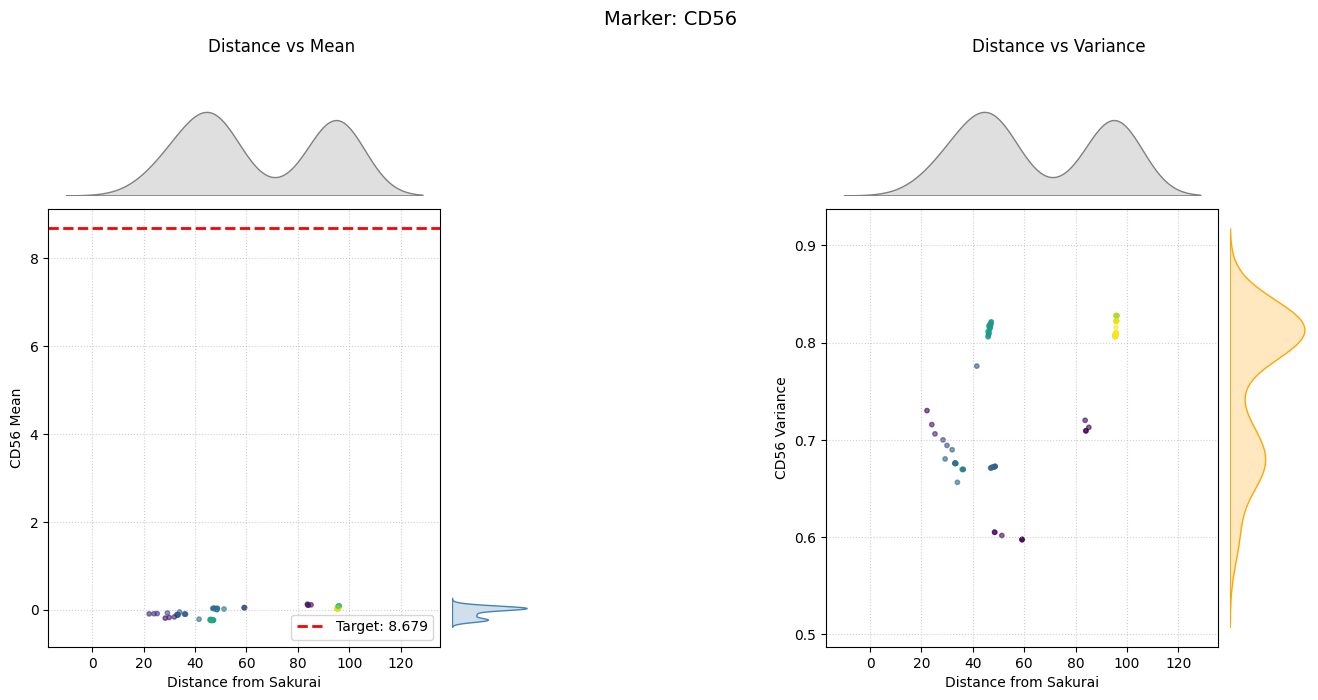

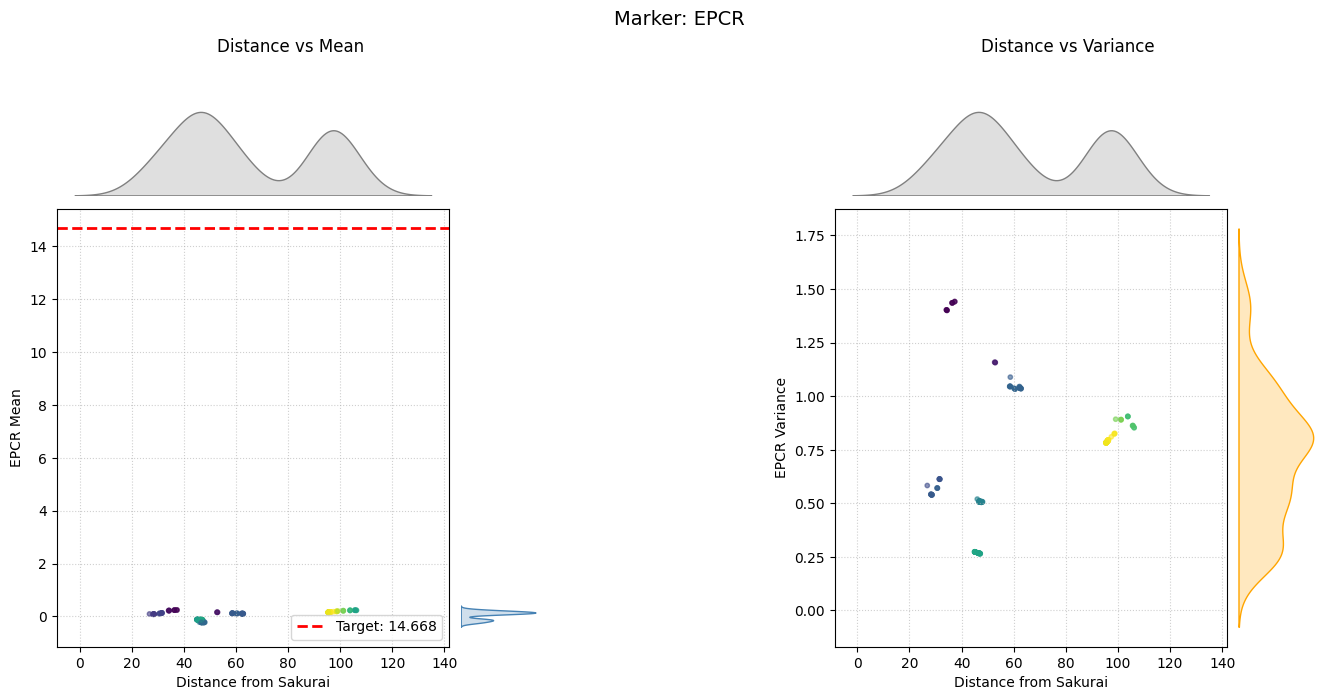

In [20]:
for marker_name, df in target_markers_stats_dfs_dict.items():
    if len(df) == 0: continue
    mean_col   = f"{marker_name}_mean"
    var_col    = f"{marker_name}_var"
    target_col = f"{marker_name}_target"
    dist_col   = "dist_sakurai"
    target_val = df[target_col].iloc[0]

    # Drop rows with missing values (if any)
    df_clean = df[[dist_col, mean_col, var_col]].dropna()

    # ----- Prepare densities -----
    # Mean vs dist
    xy_mean = df_clean[[dist_col, mean_col]].values.T
    kde_mean = gaussian_kde(xy_mean)
    dens_mean = kde_mean(xy_mean)

    # Variance vs dist
    xy_var = df_clean[[dist_col, var_col]].values.T
    kde_var = gaussian_kde(xy_var)
    dens_var = kde_var(xy_var)

    # ----- Create figure with two sub‑figures -----
    fig = plt.figure(figsize=(14, 7))
    subfigs = fig.subfigures(1, 2, wspace=0.25)

    # ========== Left: Mean ==========
    subfig_left = subfigs[0]
    # 2×2 grid: top marginal, main, right marginal (empty top‑right)
    gs_left = subfig_left.add_gridspec(2, 2, width_ratios=[5, 1], height_ratios=[1, 5],
                                       hspace=0.05, wspace=0.05)
    ax_main_left  = subfig_left.add_subplot(gs_left[1, 0])
    ax_top_left   = subfig_left.add_subplot(gs_left[0, 0], sharex=ax_main_left)
    ax_right_left = subfig_left.add_subplot(gs_left[1, 1], sharey=ax_main_left)

    # Scatter + target line
    ax_main_left.scatter(df_clean[dist_col], df_clean[mean_col], c=dens_mean,
                         cmap='viridis', alpha=0.6, s=10, rasterized=True)
    ax_main_left.axhline(target_val, color='red', linestyle='--', linewidth=2,
                         label=f'Target: {target_val:.3f}')
    ax_main_left.set_xlabel("Distance from Sakurai")
    ax_main_left.set_ylabel(f"{marker_name} Mean")
    ax_main_left.legend()
    ax_main_left.grid(True, linestyle=':', alpha=0.6)

    # Marginals
    sns.kdeplot(data=df_clean, x=dist_col, fill=True, color='gray', ax=ax_top_left)
    ax_top_left.axis('off')
    ax_top_left.set_xlim(ax_main_left.get_xlim())

    sns.kdeplot(data=df_clean, y=mean_col, fill=True, color='steelblue', ax=ax_right_left)
    ax_right_left.axis('off')
    ax_right_left.set_ylim(ax_main_left.get_ylim())

    subfig_left.suptitle("Distance vs Mean", fontsize=12)

    # ========== Right: Variance ==========
    subfig_right = subfigs[1]
    gs_right = subfig_right.add_gridspec(2, 2, width_ratios=[5, 1], height_ratios=[1, 5],
                                         hspace=0.05, wspace=0.05)
    ax_main_right  = subfig_right.add_subplot(gs_right[1, 0])
    ax_top_right   = subfig_right.add_subplot(gs_right[0, 0], sharex=ax_main_right)
    ax_right_right = subfig_right.add_subplot(gs_right[1, 1], sharey=ax_main_right)

    ax_main_right.scatter(df_clean[dist_col], df_clean[var_col], c=dens_var,
                          cmap='viridis', alpha=0.6, s=10, rasterized=True)
    ax_main_right.set_xlabel("Distance from Sakurai")
    ax_main_right.set_ylabel(f"{marker_name} Variance")
    ax_main_right.grid(True, linestyle=':', alpha=0.6)

    sns.kdeplot(data=df_clean, x=dist_col, fill=True, color='gray', ax=ax_top_right)
    ax_top_right.axis('off')
    ax_top_right.set_xlim(ax_main_right.get_xlim())

    sns.kdeplot(data=df_clean, y=var_col, fill=True, color='orange', ax=ax_right_right)
    ax_right_right.axis('off')
    ax_right_right.set_ylim(ax_main_right.get_ylim())

    subfig_right.suptitle("Distance vs Variance", fontsize=12)

    fig.suptitle(f"Marker: {marker_name}", fontsize=14, y=1.02)
    plt.show()
    # plt.savefig(f'plots/{marker_name}_dist_scatter.png', dpi=150, bbox_inches='tight')


### Plot Distance from Target Marker.

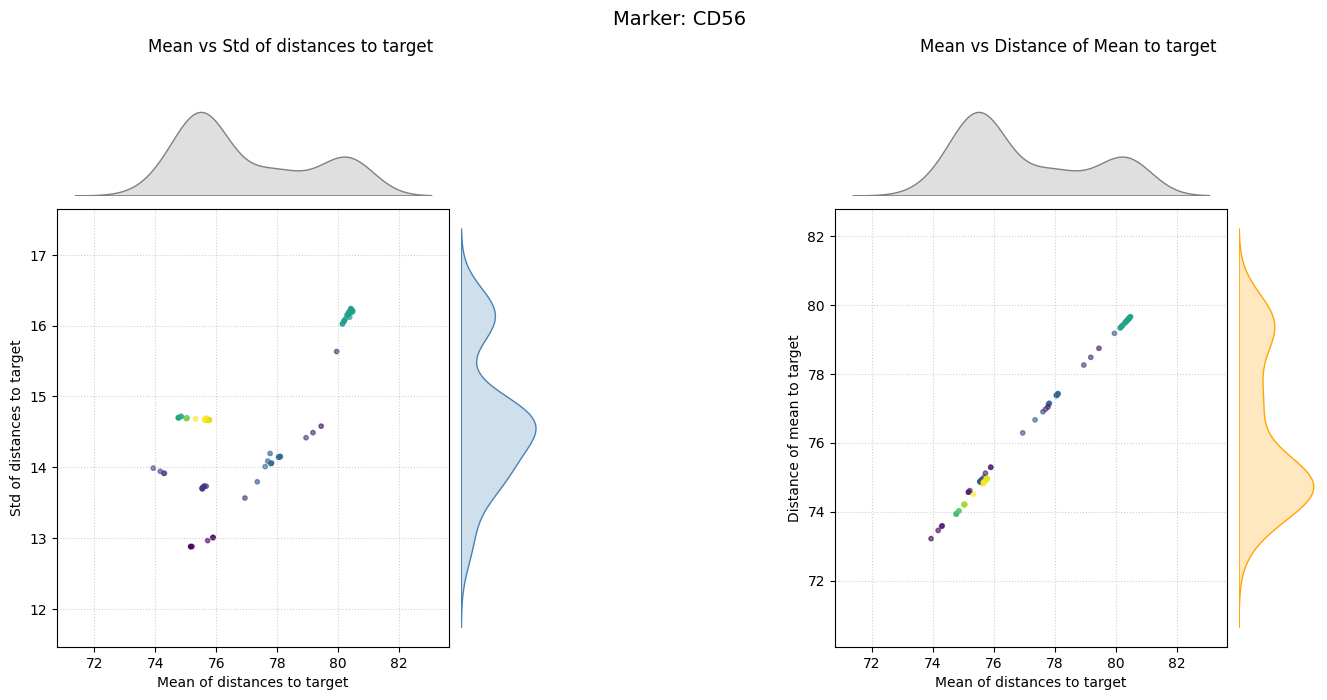

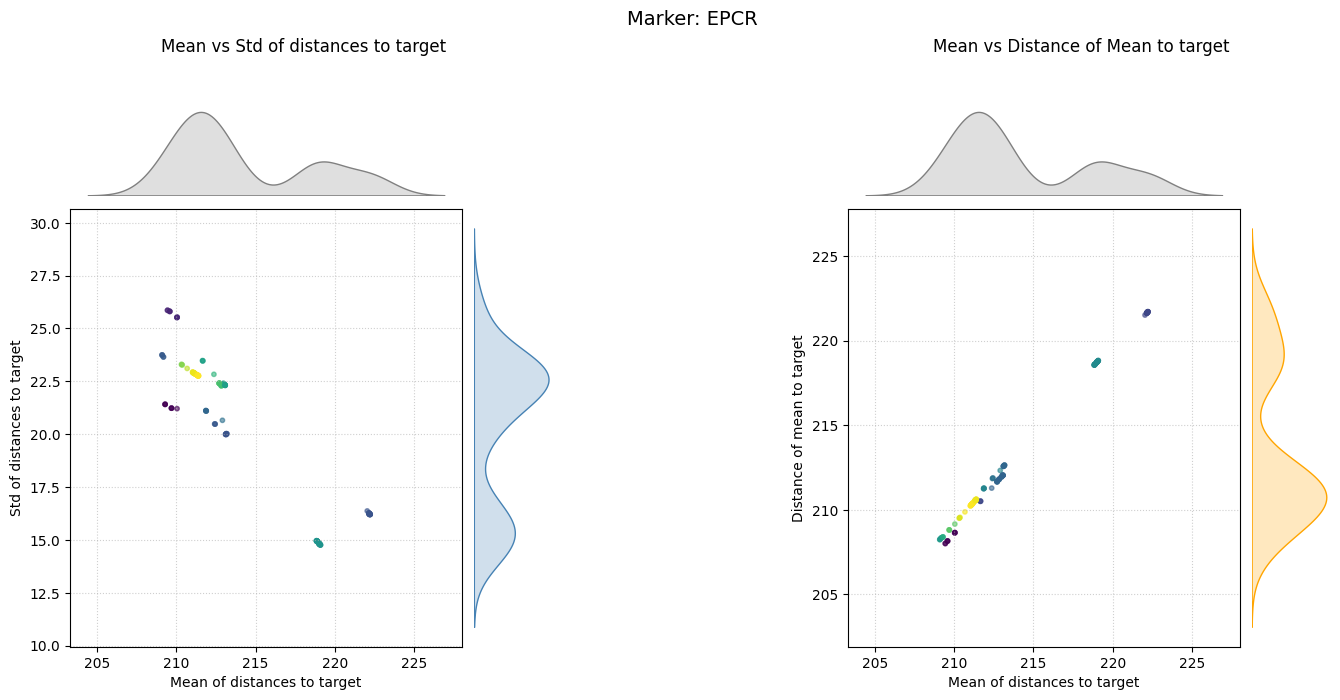

In [21]:
for marker_name, df in target_markers_stats_dfs_dict.items():
    if len(df) == 0: continue
    # Columns we need
    mean_dist_col = "mean_of_dists_to_target_marker"
    std_dist_col  = "std_of_dists_to_target_marker"
    dist_mean_col = "dist_of_mean_to_target"

    # Drop rows with missing data in those columns
    df_clean = df[[mean_dist_col, std_dist_col, dist_mean_col]].dropna()

    # ---------- Prepare joint densities ----------
    # Left panel: mean vs std
    xy_left = df_clean[[mean_dist_col, std_dist_col]].values.T
    kde_left = gaussian_kde(xy_left)
    dens_left = kde_left(xy_left)

    # Right panel: mean vs dist_of_mean
    xy_right = df_clean[[mean_dist_col, dist_mean_col]].values.T
    kde_right = gaussian_kde(xy_right)
    dens_right = kde_right(xy_right)

    # ---------- Create figure with two sub‑figures ----------
    fig = plt.figure(figsize=(14, 7))
    subfigs = fig.subfigures(1, 2, wspace=0.25)

    # ========== Left sub‑figure: Mean vs Std ==========
    subfig_left = subfigs[0]
    gs_left = subfig_left.add_gridspec(2, 2, width_ratios=[5, 1],
                                       height_ratios=[1, 5],
                                       hspace=0.05, wspace=0.05)
    ax_main_left  = subfig_left.add_subplot(gs_left[1, 0])
    ax_top_left   = subfig_left.add_subplot(gs_left[0, 0], sharex=ax_main_left)
    ax_right_left = subfig_left.add_subplot(gs_left[1, 1], sharey=ax_main_left)

    # Scatter
    ax_main_left.scatter(df_clean[mean_dist_col], df_clean[std_dist_col],
                         c=dens_left, cmap='viridis', alpha=0.6, s=10,
                         rasterized=True)
    ax_main_left.set_xlabel("Mean of distances to target")
    ax_main_left.set_ylabel("Std of distances to target")
    ax_main_left.grid(True, linestyle=':', alpha=0.6)

    # Marginals
    sns.kdeplot(data=df_clean, x=mean_dist_col, fill=True, color='gray', ax=ax_top_left)
    ax_top_left.axis('off')
    ax_top_left.set_xlim(ax_main_left.get_xlim())

    sns.kdeplot(data=df_clean, y=std_dist_col, fill=True, color='steelblue', ax=ax_right_left)
    ax_right_left.axis('off')
    ax_right_left.set_ylim(ax_main_left.get_ylim())

    subfig_left.suptitle("Mean vs Std of distances to target", fontsize=12)

    # ========== Right sub‑figure: Mean vs Dist of Mean ==========
    subfig_right = subfigs[1]
    gs_right = subfig_right.add_gridspec(2, 2, width_ratios=[5, 1],
                                         height_ratios=[1, 5],
                                         hspace=0.05, wspace=0.05)
    ax_main_right  = subfig_right.add_subplot(gs_right[1, 0])
    ax_top_right   = subfig_right.add_subplot(gs_right[0, 0], sharex=ax_main_right)
    ax_right_right = subfig_right.add_subplot(gs_right[1, 1], sharey=ax_main_right)

    ax_main_right.scatter(df_clean[mean_dist_col], df_clean[dist_mean_col],
                          c=dens_right, cmap='viridis', alpha=0.6, s=10,
                          rasterized=True)
    ax_main_right.set_xlabel("Mean of distances to target")
    ax_main_right.set_ylabel("Distance of mean to target")
    ax_main_right.grid(True, linestyle=':', alpha=0.6)

    sns.kdeplot(data=df_clean, x=mean_dist_col, fill=True, color='gray', ax=ax_top_right)
    ax_top_right.axis('off')
    ax_top_right.set_xlim(ax_main_right.get_xlim())

    sns.kdeplot(data=df_clean, y=dist_mean_col, fill=True, color='orange', ax=ax_right_right)
    ax_right_right.axis('off')
    ax_right_right.set_ylim(ax_main_right.get_ylim())

    subfig_right.suptitle("Mean vs Distance of Mean to target", fontsize=12)

    fig.suptitle(f"Marker: {marker_name}", fontsize=14, y=1.02)
    plt.show()
    # Optionally save: plt.savefig(f'plots/{marker_name}_distances.png', dpi=150, bbox_inches='tight')


### Plot Distribution of Distances for Condition with Minimum Mean of Distances from Target.

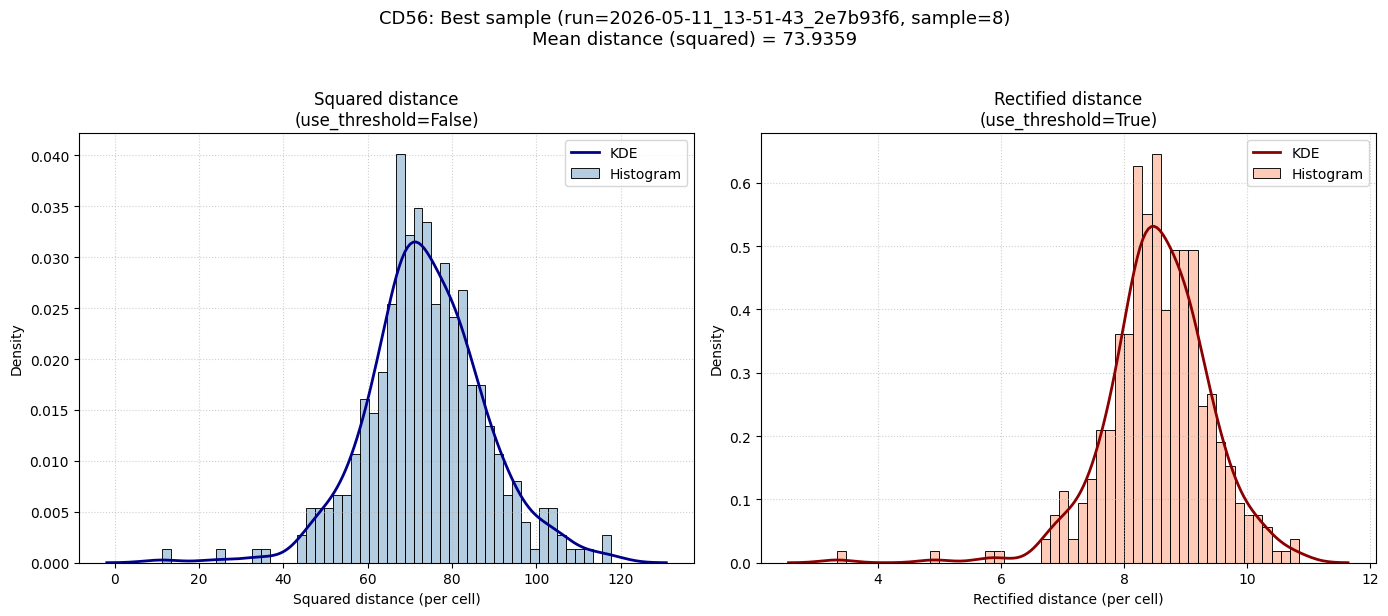

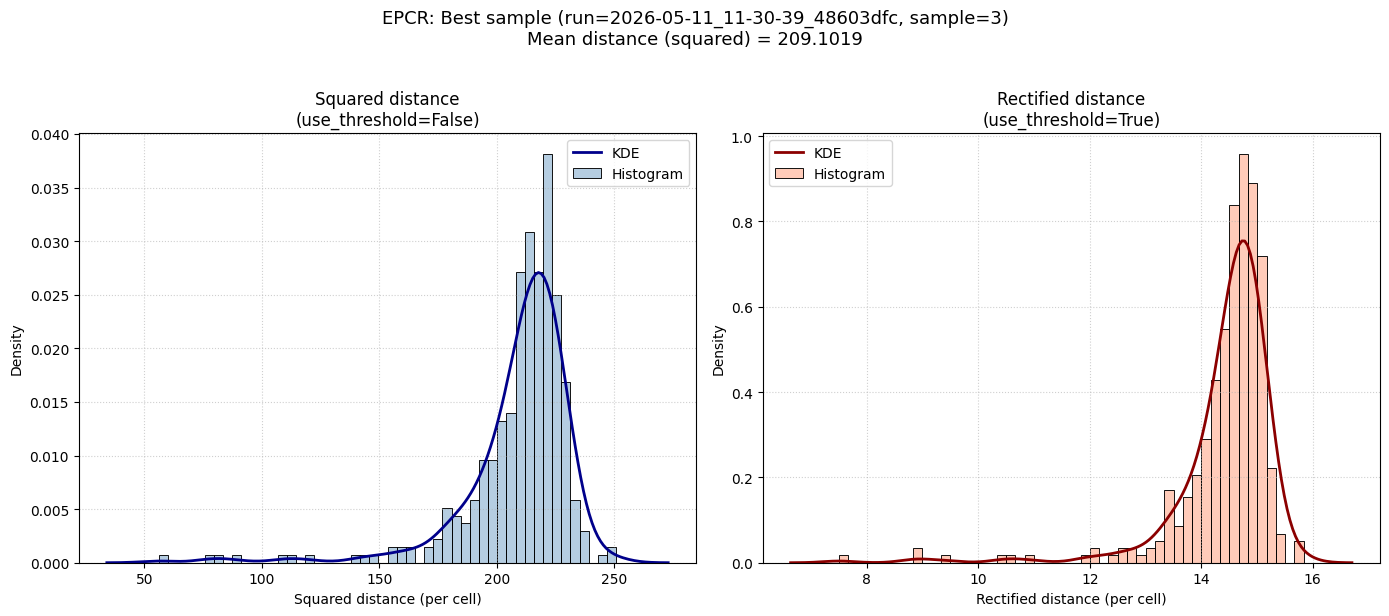

In [22]:
for marker_name, df in target_markers_stats_dfs_dict.items():
    if len(df) == 0: continue
    # ---- Best sample (lowest mean distance) ----
    idx_min = df['mean_of_dists_to_target_marker'].idxmin()
    row_best = df.loc[idx_min]
    run, opt_mode, tgt_marker, sample_idx = (
        row_best['run'], row_best['opt_mode'],
        row_best['tgt_marker'], row_best['sample_idx']
    )

    # ---- Recover that sample's data (same as in building) ----
    key = (opt_mode, tgt_marker, run)
    fwd_dict_run = fwd_results_mapped[key].copy()
    inv_dict_run = inv_results_mapped[key].copy()

    lambda_history = inv_dict_run.pop("lambda_history")[0]
    inv_dict_run["lambda_history"] = lambda_history
    n_samples = lambda_history.shape[0]

    xstar = inv_dict_run.pop("xstar")[0]
    inv_dict_run["xstar"] = np.repeat(xstar[None], n_samples, axis=0)

    fwd_dict = {k: v[sample_idx] for k, v in fwd_dict_run.items()}
    inv_dict = {k: v[sample_idx] for k, v in inv_dict_run.items()}

    X = fwd_dict["X"]
    xstar_sample = inv_dict["xstar"]

    marker_idxs = [feature_names.index(marker_name)]
    X_tgt = X[:, marker_idxs]          # (n_cells, 1)
    xstar_tgt = xstar_sample[marker_idxs]

    # ---- Compute distances for both modes ----
    # Squared distances (use_threshold=False)
    dist_squared = np.sum((X_tgt - xstar_tgt) ** 2, axis=1)

    # Rectified distance (use_threshold=True)
    dist_rect = np.maximum(xstar_tgt - X_tgt, 0).sum(axis=1)

    # ---- Create figure with two side-by-side panels ----
    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 6))

    # Left: squared distances
    sns.histplot(dist_squared, bins=50, stat='density', alpha=0.4, color='steelblue',
                 ax=ax_left, label='Histogram')
    sns.kdeplot(dist_squared, color='darkblue', linewidth=2, ax=ax_left, label='KDE')
    ax_left.set_xlabel('Squared distance (per cell)')
    ax_left.set_ylabel('Density')
    ax_left.set_title('Squared distance\n(use_threshold=False)')
    ax_left.legend()
    ax_left.grid(True, linestyle=':', alpha=0.6)

    # Right: rectified distances
    sns.histplot(dist_rect, bins=50, stat='density', alpha=0.4, color='coral',
                 ax=ax_right, label='Histogram')
    sns.kdeplot(dist_rect, color='darkred', linewidth=2, ax=ax_right, label='KDE')
    ax_right.set_xlabel('Rectified distance (per cell)')
    ax_right.set_ylabel('Density')
    ax_right.set_title('Rectified distance\n(use_threshold=True)')
    ax_right.legend()
    ax_right.grid(True, linestyle=':', alpha=0.6)

    fig.suptitle(f'{marker_name}: Best sample (run={run}, sample={sample_idx})\n'
                 f'Mean distance (squared) = {row_best["mean_of_dists_to_target_marker"]:.4f}',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
    # Optional save: plt.savefig(f'plots/{marker_name}_distance_comparison.png', dpi=150, bbox_inches='tight')


### Plot UMAP per Target Marker, Color by Predicted Cell type and Markers.

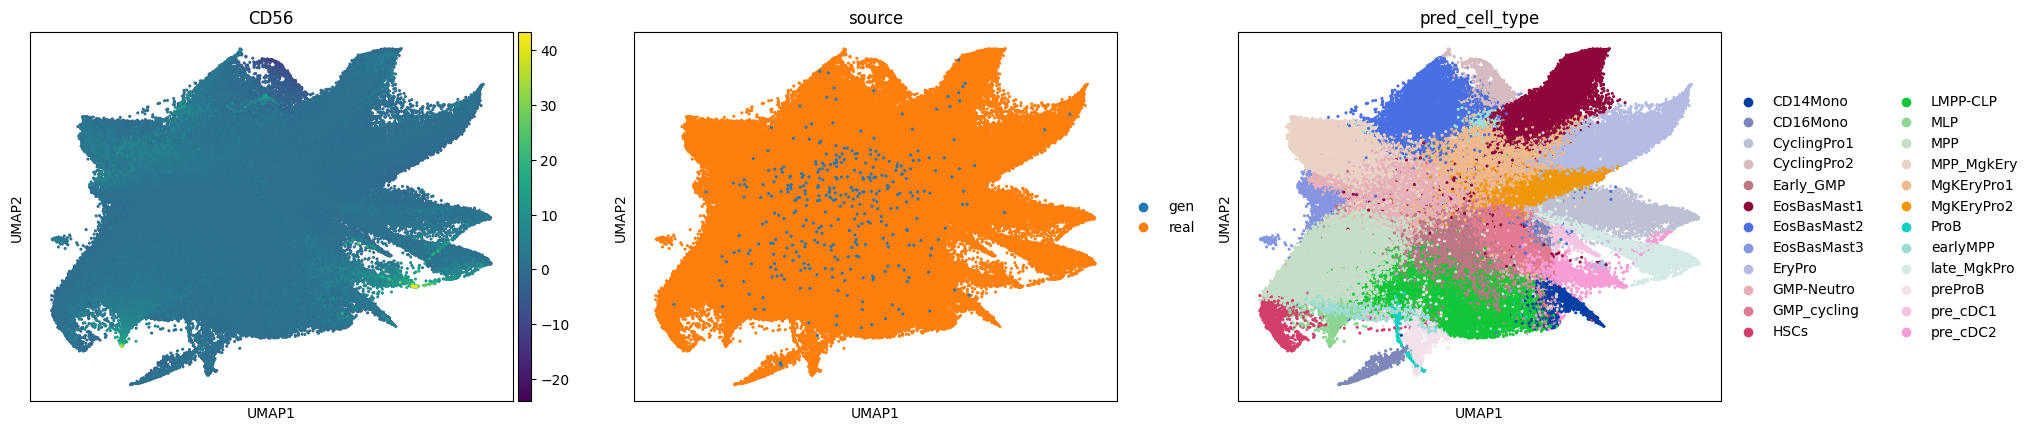

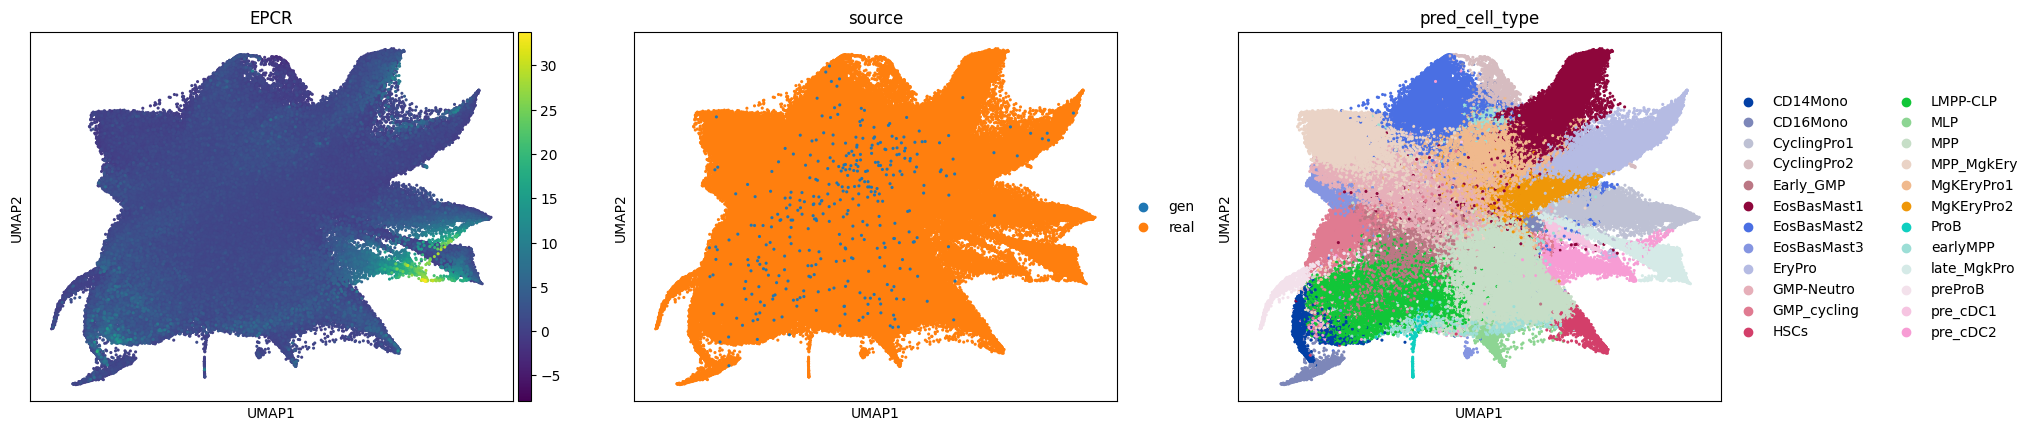

In [23]:
markers_adata = {}

for marker_name, df in target_markers_stats_dfs_dict.items():
    if len(df) == 0: continue
    # ---- Best sample (lowest mean distance) ----
    idx_min = df['mean_of_dists_to_target_marker'].idxmin()
    row_best = df.loc[idx_min]
    run, opt_mode, tgt_marker, sample_idx = (
        row_best['run'], row_best['opt_mode'],
        row_best['tgt_marker'], row_best['sample_idx']
    )

    # ---- Recover that sample's data (same as in building) ----
    key = (opt_mode, tgt_marker, run)
    fwd_dict_run = fwd_results_mapped[key].copy()
    inv_dict_run = inv_results_mapped[key].copy()

    lambda_history = inv_dict_run.pop("lambda_history")[0]
    inv_dict_run["lambda_history"] = lambda_history
    n_samples = lambda_history.shape[0]

    xstar = inv_dict_run.pop("xstar")[0]
    inv_dict_run["xstar"] = np.repeat(xstar[None], n_samples, axis=0)

    fwd_dict = {k: v[sample_idx] for k, v in fwd_dict_run.items()}
    inv_dict = {k: v[sample_idx] for k, v in inv_dict_run.items()}

    X_channel_gen = fwd_dict["X_channel"]
    X_scatter_gen = fwd_dict["X_scatter"]
    ct_probs_gen = fwd_dict["ct_probs"]
    xstar_sample = inv_dict["xstar"]

    ct_label_gen = np.argmax(ct_probs_gen, axis=1)
    ct_gen = ct_le.inverse_transform(ct_label_gen)

    n_gen_cells = X_channel_gen.shape[0]

    # create anndata
    X_channel_joint = np.concatenate(
        (X_channel_ref, X_channel_gen), axis=0
    )
    X_scatter_joint = np.concatenate(
        (X_scatter_ref, X_scatter_gen), axis=0
    )
    ct_joint = np.concatenate(
        (adata.obs["pred_cell_type"], ct_gen), axis=0
    )

    cond_gen = np.repeat(row_best[protocol_cols].values[None], n_gen_cells, axis=0)
    cond_ref = adata.obs[protocol_cols].astype(float).values

    cond_joint = np.concatenate(
        (cond_ref, cond_gen), axis=0
    )


    # create obs
    obs = {
        "pred_cell_type": ct_joint,
        **{
            col: X_scatter_joint[:, idx] for idx, col in enumerate(scatter_cols)
        },
        **{
            col: cond_joint[:, idx] for idx, col in enumerate(protocol_cols)
        },
        "source": ["real"]*adata.shape[0] + ["gen"]*n_gen_cells
        
    }
    adata_joint = sc.AnnData(
        X=X_channel_joint,
        obs=obs,
        var=pd.DataFrame(index=adata.var_names)
    )

    sc.pp.neighbors(adata_joint)
    sc.tl.umap(adata_joint)

    color = [
        marker_name,
        "source",
        "pred_cell_type",
    ]
    sc.pl.embedding(adata_joint, "umap", color=color, s=20, frameon=True)